# SDG3 — GRU Experiments

This notebook contains **3 GRU experiments**:
- **Exp 1**: Basic GRU (unidirectional, single layer)
- **Exp 2**: Bidirectional GRU (BiGRU)
- **Exp 3**: Bidirectional GRU + Attention





## 0. Install & Import Dependencies

In [1]:
!pip install -q torch torchtext scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.0 MB/s eta 0:00:00


In [2]:
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (hamming_loss, f1_score,
                              accuracy_score, precision_score, recall_score)

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
sns.set_context('notebook'); sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
STOP_WORDS = set(stopwords.words('english'))
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Data

In [3]:
from google.colab import files

print('Upload Devex_train.csv')
uploaded = files.upload()
train_filename = [k for k in uploaded.keys() if 'train' in k.lower()][0]

print('\nUpload Devex_test_questions.csv')
uploaded2 = files.upload()
test_filename = [k for k in uploaded2.keys()][0]

Upload Devex_train.csv


Saving Devex_train.csv to Devex_train.csv

Upload Devex_test_questions.csv


Saving Devex_test_questions.csv to Devex_test_questions.csv


In [4]:

train_df = pd.read_csv("/content/Devex_train.csv", encoding='latin1')
test_df  = pd.read_csv("/content/Devex_test_questions.csv", encoding='latin1')

# Label columns are Label 1 through Label 12
label_cols_raw = [f'Label {i}' for i in range(1, 13)]

# Get all unique indicator codes across all label columns
all_indicators = []
for col in label_cols_raw:
    all_indicators.extend(train_df[col].dropna().tolist())

def extract_code(label):
    return str(label).split(' - ')[0].strip()

unique_indicators = sorted(set(extract_code(x) for x in all_indicators))
label_to_index    = {label: idx for idx, label in enumerate(unique_indicators)}
NUM_LABELS        = len(unique_indicators)
label_cols        = unique_indicators

# Build Y matrix
def encode_labels(row):
    vector = [0] * NUM_LABELS
    for col in label_cols_raw:
        if pd.notna(row[col]):
            code = extract_code(row[col])
            if code in label_to_index:
                vector[label_to_index[code]] = 1
    return vector

Y_all = np.array([encode_labels(row) for _, row in train_df.iterrows()], dtype=np.int32)

# Text column
train_df['__text__'] = train_df['Text'].fillna('').str.strip()
test_df['__text__']  = test_df['Text'].fillna('').str.strip()

ID_COL = 'Unique ID'

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Num labels  : {NUM_LABELS}')
print(f'Labels      : {label_cols}')
print(f'Y shape     : {Y_all.shape}')

Train shape : (2995, 16)
Test shape  : (998, 4)
Num labels  : 27
Labels      : ['3.1.1', '3.1.2', '3.2.1', '3.2.2', '3.3.1', '3.3.2', '3.3.3', '3.3.4', '3.3.5', '3.4.1', '3.4.2', '3.5.1', '3.5.2', '3.6.1', '3.7.1', '3.7.2', '3.8.1', '3.8.2', '3.9.1', '3.9.2', '3.9.3', '3.a.1', '3.b.1', '3.b.2', '3.b.3', '3.c.1', '3.d.1']
Y shape     : (2995, 27)


## 2. Preprocessing & Vocabulary

In [5]:
def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_WORDS]
    return ' '.join(tokens)

train_texts = train_df['__text__'].apply(normalize_text).tolist()
test_texts  = test_df['__text__'].apply(normalize_text).tolist()
print(f'Example: {train_texts[0][:120]}')

Example: centers biomedical research excellence cobre phase iii transitional centers funding opportunity description institutiona


In [6]:
# Build vocabulary from training corpus
MAX_VOCAB  = 30_000
MAX_SEQ_LEN = 256
PAD_IDX    = 0
UNK_IDX    = 1

counter = Counter()
for text in train_texts:
    counter.update(text.split())

vocab = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE}')

def encode(text: str) -> list:
    tokens = text.split()[:MAX_SEQ_LEN]
    return [word2idx.get(t, UNK_IDX) for t in tokens]

def pad(seq: list, length: int) -> list:
    return seq[:length] + [PAD_IDX] * max(0, length - len(seq))

Vocabulary size: 29443


In [7]:

class SDGDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = [pad(encode(t), MAX_SEQ_LEN) for t in texts]
        self.labels = labels  # numpy array or None

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        x = torch.tensor(self.encodings[idx], dtype=torch.long)
        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.float)
            return x, y
        return x



# 80/20 train/val split
tr_texts, val_texts, Y_tr, Y_val = train_test_split(
    train_texts, Y_all, test_size=0.2, random_state=42
)

tr_dataset  = SDGDataset(tr_texts,  Y_tr)
val_dataset = SDGDataset(val_texts, Y_val)
test_dataset = SDGDataset(test_texts)

BATCH_SIZE = 32
tr_loader   = DataLoader(tr_dataset,   batch_size=BATCH_SIZE, shuffle=True)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f'Train batches: {len(tr_loader)} | Val batches: {len(val_loader)}')

Train batches: 75 | Val batches: 19


## 3. Training & Evaluation Utilities

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, Y in loader:
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, Y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def get_probas(model, loader):
    model.eval()
    all_p = []
    for batch in loader:
        X = batch[0] if isinstance(batch, (list, tuple)) else batch
        X = X.to(DEVICE)
        p = torch.sigmoid(model(X)).cpu().numpy()
        all_p.append(p)
    return np.vstack(all_p)


def tune_thresholds(P, Y_true, steps=np.arange(0.1, 0.91, 0.05)):
    thresholds = []
    for i in range(P.shape[1]):
        best_t, best_f1 = 0.5, 0.0
        for t in steps:
            f = f1_score(Y_true[:, i], (P[:, i] >= t).astype(int), zero_division=0)
            if f > best_f1:
                best_f1, best_t = f, t
        thresholds.append(best_t)
    return np.array(thresholds)


def evaluate_probas(name, P, Y_true, threshold=0.5):
    if isinstance(threshold, np.ndarray):
        Y_pred = (P >= threshold).astype(np.int32)
    else:
        Y_pred = (P >= threshold).astype(np.int32)

    hl  = hamming_loss(Y_true, Y_pred)
    mf1 = f1_score(Y_true, Y_pred, average='macro',   zero_division=0)
    acc = accuracy_score(Y_true, Y_pred)
    sf1 = f1_score(Y_true, Y_pred, average='samples', zero_division=0)
    pr  = precision_score(Y_true, Y_pred, average='macro', zero_division=0)
    rc  = recall_score(Y_true, Y_pred, average='macro', zero_division=0)
    print(f'[{name}]  Hamming={hl:.4f}  Acc={acc:.4f}  Macro-F1={mf1:.4f}  '
      f'Sample-F1={sf1:.4f}  Prec={pr:.4f}  Rec={rc:.4f}')
    return {'experiment': name, 'hamming_loss': hl, 'accuracy': acc,
        'macro_f1': mf1, 'sample_f1': sf1, 'precision': pr, 'recall': rc,
        'pred': Y_pred, 'proba': P}


def fit_model(model, epochs=10, lr=1e-3, patience=3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_loss, no_improve = float('inf'), 0
    history = []

    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, tr_loader, optimizer, criterion)

        # validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X, Y in val_loader:
                X, Y = X.to(DEVICE), Y.to(DEVICE)
                val_loss += criterion(model(X), Y).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        history.append({'epoch': epoch, 'train_loss': tr_loss, 'val_loss': val_loss})
        print(f'  Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={val_loss:.4f}')

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), '_best_weights.pt')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(torch.load('_best_weights.pt'))
    return model, pd.DataFrame(history)


def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['epoch'], history['train_loss'], label='Train Loss')
    ax.plot(history['epoch'], history['val_loss'],   label='Val Loss')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.legend(); plt.tight_layout(); plt.show()

gru_results = []
print('Utilities ready.')

Utilities ready.


---
## Exp 1 — Basic GRU

**Architecture:** Embedding → single-layer unidirectional GRU → take final hidden state → Dropout → Linear classifier.



Training Experiment 1: Basic GRU
Parameters: 3,871,259
  Epoch 01 | train_loss=0.3510 | val_loss=0.2338
  Epoch 02 | train_loss=0.2399 | val_loss=0.2347
  Epoch 03 | train_loss=0.2400 | val_loss=0.2337
  Epoch 04 | train_loss=0.2375 | val_loss=0.2321
  Epoch 05 | train_loss=0.2343 | val_loss=0.2299
  Epoch 06 | train_loss=0.2312 | val_loss=0.2259
  Epoch 07 | train_loss=0.2226 | val_loss=0.2204
  Epoch 08 | train_loss=0.2151 | val_loss=0.2170
  Epoch 09 | train_loss=0.2083 | val_loss=0.2131
  Epoch 10 | train_loss=0.2006 | val_loss=0.2095
  Epoch 11 | train_loss=0.1943 | val_loss=0.2043
  Epoch 12 | train_loss=0.1870 | val_loss=0.2037
  Epoch 13 | train_loss=0.1794 | val_loss=0.1987
  Epoch 14 | train_loss=0.1737 | val_loss=0.1974
  Epoch 15 | train_loss=0.1687 | val_loss=0.1911


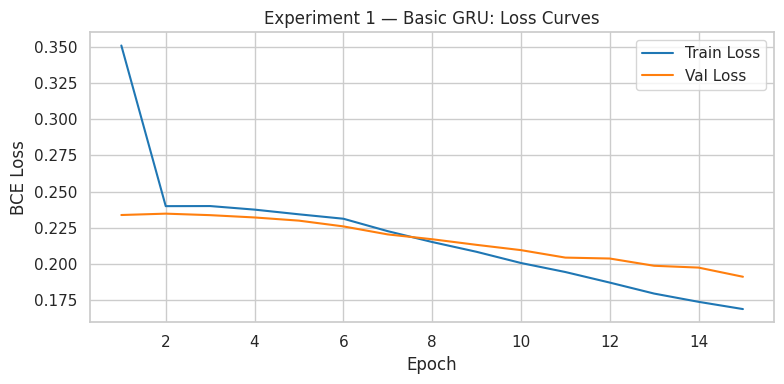

[exp01_basic_gru]  Hamming=0.0607  Acc=0.2104  Macro-F1=0.1108  Sample-F1=0.3414  Prec=0.1990  Rec=0.0921


In [9]:
# Define the Basic GRU model architecture
# Single layer, unidirectional GRU that reads text left to right
class BasicGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))          # (batch, seq, embed)
        _, hidden = self.gru(emb)                      # hidden: (1, batch, hidden)
        out = self.dropout(hidden.squeeze(0))          # (batch, hidden)
        return self.fc(out)                            # (batch, num_labels)


print('Training Experiment 1: Basic GRU')
model_01 = BasicGRU(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
    num_labels=NUM_LABELS, dropout=0.3
).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model_01.parameters()):,}')

model_01, hist_01 = fit_model(model_01, epochs=15, lr=1e-3, patience=3)
plot_history(hist_01, 'Experiment 1 — Basic GRU: Loss Curves')

P_val_01 = get_probas(model_01, val_loader)
r01 = evaluate_probas('exp01_basic_gru', P_val_01, Y_val, threshold=0.5)
gru_results.append(r01)

---
## Exp 2— Bidirectional GRU (BiGRU)

**Architecture:** Embedding → bidirectional GRU → concatenate forward + backward final hidden states → Dropout → Linear classifier.



Training Exp 2: Bidirectional GRU
Parameters: 3,973,787
  Epoch 01 | train_loss=0.3412 | val_loss=0.2300
  Epoch 02 | train_loss=0.2323 | val_loss=0.2252
  Epoch 03 | train_loss=0.2211 | val_loss=0.2146
  Epoch 04 | train_loss=0.2046 | val_loss=0.1989
  Epoch 05 | train_loss=0.1870 | val_loss=0.1871
  Epoch 06 | train_loss=0.1715 | val_loss=0.1790
  Epoch 07 | train_loss=0.1567 | val_loss=0.1708
  Epoch 08 | train_loss=0.1442 | val_loss=0.1663
  Epoch 09 | train_loss=0.1332 | val_loss=0.1614
  Epoch 10 | train_loss=0.1233 | val_loss=0.1569
  Epoch 11 | train_loss=0.1143 | val_loss=0.1554
  Epoch 12 | train_loss=0.1058 | val_loss=0.1541
  Epoch 13 | train_loss=0.1009 | val_loss=0.1577
  Epoch 14 | train_loss=0.0926 | val_loss=0.1552
  Epoch 15 | train_loss=0.0872 | val_loss=0.1567
  Early stopping at epoch 15.


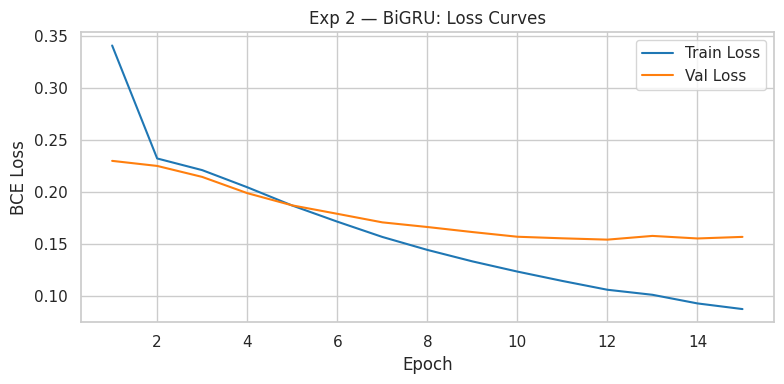

[exp2_bigru]  Hamming=0.0512  Acc=0.3155  Macro-F1=0.3388  Sample-F1=0.5251  Prec=0.6281  Rec=0.2667


In [10]:
class BiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional → hidden_dim * 2
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))          # (batch, seq, embed)
        _, hidden = self.gru(emb)                      # hidden: (2, batch, hidden)
        # concatenate forward and backward final states
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        out = self.dropout(out)
        return self.fc(out)                            # (batch, num_labels)


print('Training Exp 2: Bidirectional GRU')
model_02 = BiGRU(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
    num_labels=NUM_LABELS, dropout=0.3
).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model_02.parameters()):,}')

model_02, hist_08 = fit_model(model_02, epochs=15, lr=1e-3, patience=3)
plot_history(hist_08, 'Exp 2 — BiGRU: Loss Curves')

P_val_08 = get_probas(model_02, val_loader)
r08 = evaluate_probas('exp2_bigru', P_val_08, Y_val, threshold=0.5)
gru_results.append(r08)

---
## Exp 3 — Bidirectional GRU + Self-Attention

**Architecture:** Embedding → BiGRU over all timesteps → learnable self-attention over hidden states → weighted sum pooling → Dropout → Linear classifier.

Training Exp 3: BiGRU + Self-Attention
Parameters: 3,974,043
  Epoch 01 | train_loss=0.3254 | val_loss=0.2289
  Epoch 02 | train_loss=0.2258 | val_loss=0.2100
  Epoch 03 | train_loss=0.2016 | val_loss=0.1812
  Epoch 04 | train_loss=0.1828 | val_loss=0.1682
  Epoch 05 | train_loss=0.1699 | val_loss=0.1594
  Epoch 06 | train_loss=0.1599 | val_loss=0.1557
  Epoch 07 | train_loss=0.1515 | val_loss=0.1524
  Epoch 08 | train_loss=0.1432 | val_loss=0.1548
  Epoch 09 | train_loss=0.1369 | val_loss=0.1509
  Epoch 10 | train_loss=0.1302 | val_loss=0.1468
  Epoch 11 | train_loss=0.1238 | val_loss=0.1466
  Epoch 12 | train_loss=0.1178 | val_loss=0.1477
  Epoch 13 | train_loss=0.1124 | val_loss=0.1466
  Epoch 14 | train_loss=0.1069 | val_loss=0.1462
  Epoch 15 | train_loss=0.1037 | val_loss=0.1433


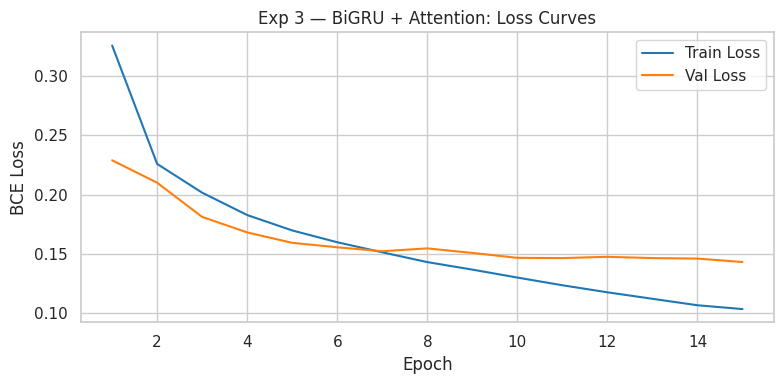

[exp3_bigru_attention]  Hamming=0.0467  Acc=0.3573  Macro-F1=0.4558  Sample-F1=0.5959  Prec=0.6576  Rec=0.3733


In [11]:
class Attention(nn.Module):
    """Additive self-attention: learns a score per timestep, softmaxed into weights."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden_states, mask=None):
        # hidden_states: (batch, seq, hidden)
        scores = self.attn(hidden_states).squeeze(-1)      # (batch, seq)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (batch, seq, 1)
        context = (weights * hidden_states).sum(dim=1)        # (batch, hidden)
        return context, weights.squeeze(-1)


class BiGRUAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.attention = Attention(hidden_dim * 2)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        mask = (x != 0).float()                            # (batch, seq)
        emb  = self.dropout(self.embedding(x))             # (batch, seq, embed)
        hs, _ = self.gru(emb)                              # (batch, seq, hidden*2)
        context, _ = self.attention(self.dropout(hs), mask)  # (batch, hidden*2)
        return self.fc(self.dropout(context))              # (batch, num_labels)


print('Training Exp 3: BiGRU + Self-Attention')
model_03 = BiGRUAttention(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
    num_labels=NUM_LABELS, dropout=0.3
).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model_03.parameters()):,}')

model_03, hist_09 = fit_model(model_03, epochs=15, lr=1e-3, patience=3)
plot_history(hist_09, 'Exp 3 — BiGRU + Attention: Loss Curves')

P_val_09 = get_probas(model_03, val_loader)
r09 = evaluate_probas('exp3_bigru_attention', P_val_09, Y_val, threshold=0.5)
gru_results.append(r09)

## 4. GRU Results Summary & Visualization

In [12]:
summary_cols = ['experiment', 'hamming_loss', 'macro_f1', 'sample_f1', 'precision', 'recall', 'accuracy']
gru_summary = (pd.DataFrame([{k: r[k] for k in summary_cols} for r in gru_results])
                 .sort_values('macro_f1', ascending=False)
                 .reset_index(drop=True))
gru_summary

,experiment,hamming_loss,macro_f1,sample_f1,precision,recall,accuracy
0,exp3_bigru_attention,0.046745,0.455838,0.595854,0.657584,0.373277,0.357262
1,exp2_bigru,0.051196,0.338797,0.525123,0.628139,0.266679,0.315526
2,exp01_basic_gru,0.060657,0.110842,0.341359,0.198954,0.092117,0.210351


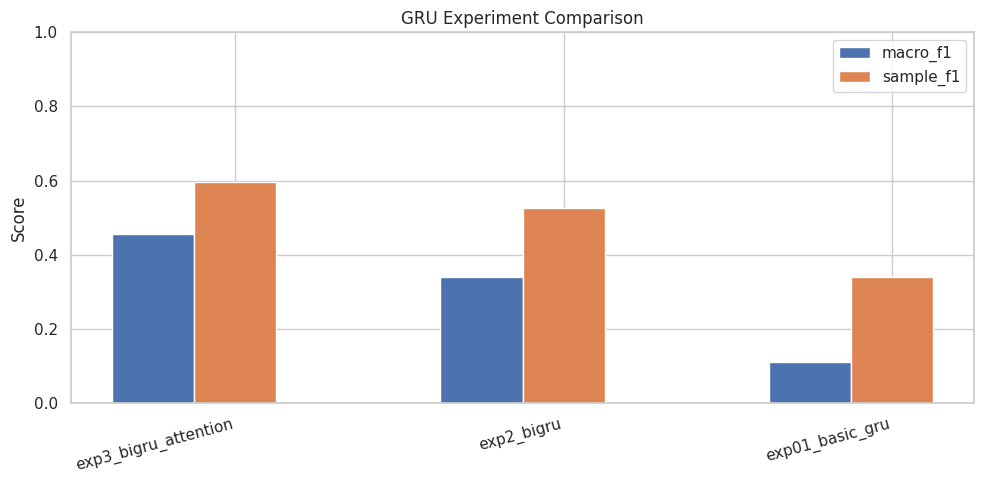

In [13]:
# Progression bar chart
exps    = gru_summary['experiment'].tolist()
metrics = ['macro_f1', 'sample_f1']
colors  = ['#4c72b0', '#dd8452',]

x = np.arange(len(exps))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, c) in enumerate(zip(metrics, colors)):
    vals = gru_summary[m].tolist()
    ax.bar(x + i * width, vals, width, label=m, color=c)

ax.set_xticks(x + width)
ax.set_xticklabels(exps, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('GRU Experiment Comparison')
ax.legend()
plt.tight_layout()
plt.show()

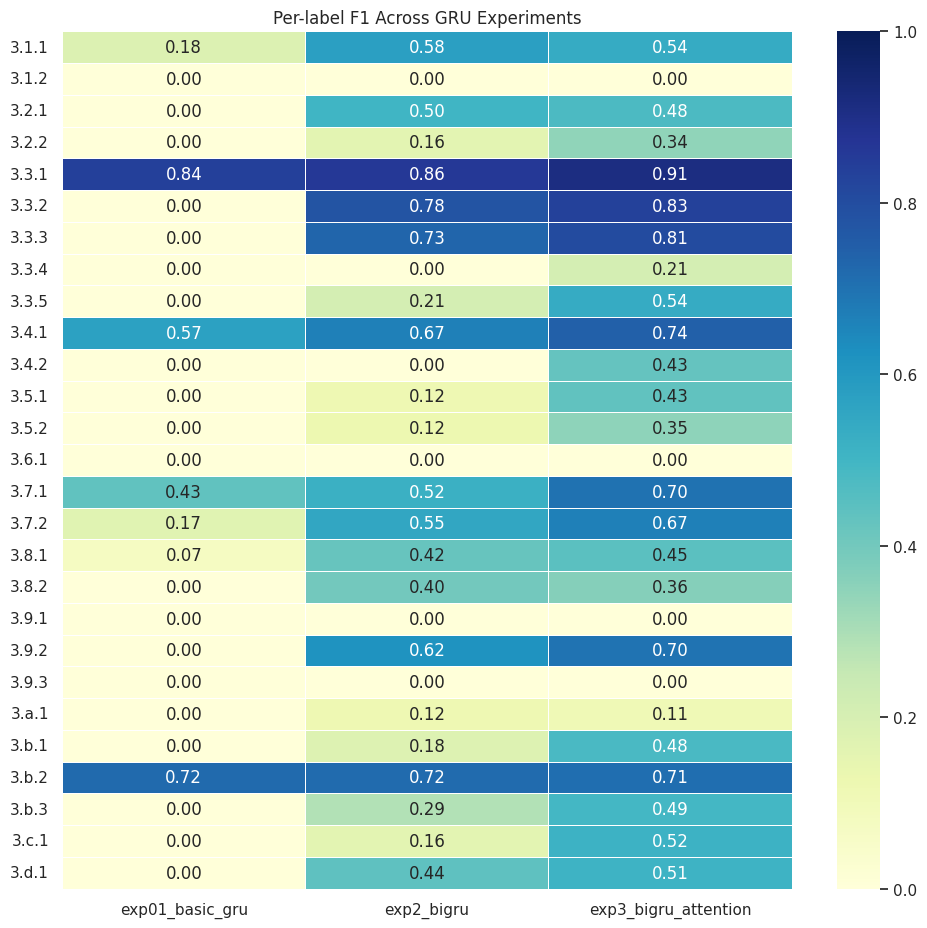

In [14]:
# Per-label F1 heatmap across GRU experiments
per_label = {}
for r in gru_results:
    per_label[r['experiment']] = [
        f1_score(Y_val[:, i].astype(np.int32), r['pred'][:, i].astype(np.int32), zero_division=0)
        for i in range(NUM_LABELS)
    ]

heatmap_df = pd.DataFrame(per_label, index=label_cols)

fig, ax = plt.subplots(figsize=(10, max(4, NUM_LABELS * 0.35)))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Per-label F1 Across GRU Experiments')
plt.tight_layout()
plt.show()

## 5. Inference on Test Set (Best GRU Model)

In [18]:
best_gru_name = gru_summary.iloc[0]['experiment']
model_map = {
    'exp01_basic_gru':      model_01,
    'exp2_bigru':           model_02,
    'exp3_bigru_attention': model_03,
}
best_model = model_map[best_gru_name]
best_proba = [r for r in gru_results if r['experiment'] == best_gru_name][0]['proba']

# Tune thresholds on validation set
opt_thr = tune_thresholds(best_proba, Y_val.astype(np.int32))
print(f'Best GRU model: {best_gru_name}')
print(f'Tuned thresholds: {np.round(opt_thr, 2)}')

# Predict on test set
P_test = get_probas(best_model, test_loader)
Y_test_pred = (P_test >= opt_thr).astype(np.int32)

# Ensure at least 1 label per document
for i in range(len(Y_test_pred)):
    if Y_test_pred[i].sum() == 0:
        Y_test_pred[i, np.argmax(P_test[i])] = 1

sub = pd.DataFrame(Y_test_pred, columns=label_cols)
if ID_COL and ID_COL in test_df.columns:
    sub.insert(0, ID_COL, test_df[ID_COL].values)

sub.to_csv('gru_submission.csv', index=False)
print(f'Submission written: gru_submission.csv ({len(sub)} rows)')
sub.head()

Best GRU model: exp3_bigru_attention
Tuned thresholds: [0.55 0.15 0.2  0.5  0.4  0.1  0.1  0.1  0.3  0.35 0.1  0.4  0.15 0.5
 0.4  0.3  0.2  0.15 0.5  0.15 0.5  0.15 0.25 0.3  0.5  0.35 0.25]
Submission written: gru_submission.csv (998 rows)


,Unique ID,3.1.1,3.1.2,3.2.1,3.2.2,3.3.1,3.3.2,3.3.3,3.3.4,3.3.5,...,3.8.2,3.9.1,3.9.2,3.9.3,3.a.1,3.b.1,3.b.2,3.b.3,3.c.1,3.d.1
0,49848,0,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,52348,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,103541,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,52382,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,47212,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
